In [1]:
from astropy.io import fits
import numpy as np
from astropy import wcs
import astropy.units as u
import scipy.constants as cst
from astropy.stats import gaussian_fwhm_to_sigma
import astropy.convolution as conv
import datetime
import matplotlib.pyplot as plt

In [2]:
file = 'fits_and_hdf5/pySIDES_from_uchuu_tile_0_1.414deg_x_1.414deg_fir_lines_res20arcsec_dnu4.0GHz_full_de_Looze_smoothed_MJy_sr.fits'
cube = fits.getdata(file)
hdr = fits.getheader(file)
reso = (hdr['CDELT1'] * u.Unit(hdr["CUNIT1"]) )
cube_mean = np.mean(cube, axis=(1,2)) * (reso**2).to(u.sr).value * 1e6

w = wcs.WCS(hdr)
#Telescope diameter 
D = 2 #m 

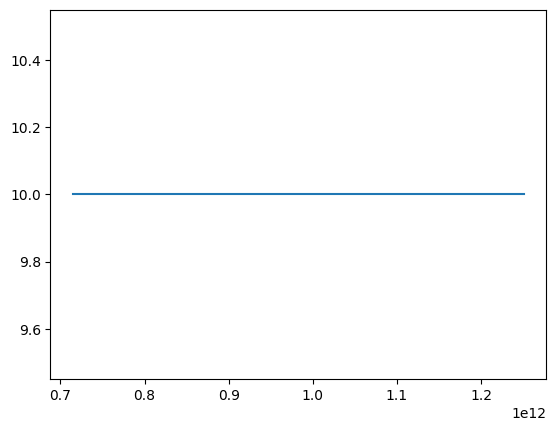

In [3]:
z = np.arange(hdr['NAXIS3'])
freq_list = ( w.swapaxes(0, 2).sub(1).wcs_pix2world(z, 0)[0] * u.Unit(hdr["CUNIT3"]) ).to(u.Hz).value
dnu = (hdr['CDELT3'] * u.Unit(hdr["CUNIT3"]) ).to(u.Hz).value
vdelt = dnu / freq_list * (cst.c*1e-3) #km/sec
fwhm = 1.22 * cst.c / (freq_list * D) * u.rad
sigma = fwhm * gaussian_fwhm_to_sigma
#Omega_beam = (2*np.pi*(sigma)**2).to(u.sr)
res = fwhm.min() / 2
sigma_pix_list = sigma / res

intensity = (res**2).to(u.sr).value*10*vdelt #Jy.km/s

map_size = hdr['NAXIS1']
center = map_size // 2

plt.plot(freq_list,intensity / (res**2).to(u.sr).value / vdelt)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Intensity [Jy/sr]')

In [4]:
for factor_on_Sigma in (1,2,5,10,20,30): 
            
    cube_1_source = np.zeros((hdr['NAXIS3'], map_size, map_size))
    cube_1_sources = cube_mean[:,None,None] / (res**2).to(u.sr).value
    cube_1_source[:, center, center] += intensity / (res**2).to(u.sr).value / vdelt  #Jy/sr

    for f, sigma_channel in enumerate(sigma_pix_list):
        kernel = conv.Gaussian2DKernel(x_stddev=sigma_channel*factor_on_Sigma, x_size=map_size)
        cube_1_source[f] = conv.convolve_fft(cube_1_source[f], kernel, normalize_kernel=True, boundary = 'wrap')

    hdr_out = hdr
    hdr_out['CDELT2'] = res.to(u.deg).value
    hdr_out['CDELT3'] = res.to(u.deg).value
    hdr_out["DATE"]  = str(datetime.datetime.now())
    hdr_out["BUNIT"] = "Jy/sr"

    # Create HDU and save
    hdu = fits.PrimaryHDU(cube_1_source, header=hdr_out)
    hdul = fits.HDUList([hdu])

    savepath = f'fits_and_hdf5/cube_1source_with_{factor_on_Sigma}xbigger_sigma_PSF.fits'
    hdul.writeto(savepath, overwrite=True)
    print('')
    print("saved ", savepath)

    for separation_in_res in (2,3,4,5,6,10,14,20):
             
        cube_1_source = np.zeros((hdr['NAXIS3'], map_size, map_size))
        cube_1_sources = cube_mean[:,None,None] / (res**2).to(u.sr).value
        cube_1_source[:, center, center-separation_in_res//2] += intensity / (res**2).to(u.sr).value / vdelt  #Jy/sr
        cube_1_source[:, center, center+separation_in_res//2] += intensity / (res**2).to(u.sr).value / vdelt  #Jy/sr

        for f, sigma_channel in enumerate(sigma_pix_list):
            kernel = conv.Gaussian2DKernel(x_stddev=sigma_channel*factor_on_Sigma, x_size=map_size)
            cube_1_source[f] = conv.convolve_fft(cube_1_source[f], kernel, normalize_kernel=True, boundary = 'wrap')

        hdr_out = hdr
        hdr_out['CDELT2'] = res.to(u.deg).value
        hdr_out['CDELT3'] = res.to(u.deg).value
        hdr_out["DATE"]  = str(datetime.datetime.now())
        hdr_out["BUNIT"] = "Jy/sr"

        # Create HDU and save
        hdu = fits.PrimaryHDU(cube_1_source, header=hdr_out)
        hdul = fits.HDUList([hdu])

        savepath = f'fits_and_hdf5/cube_2sources_separated_by_{res.to(u.arcsec).value*separation_in_res:.1f}arcsecs_with_{factor_on_Sigma}xbigger_sigma_PSF.fits'
        hdul.writeto(savepath, overwrite=True)
        
        print("saved ", savepath)
    


saved  fits_and_hdf5/cube_1source_with_1xbigger_sigma_PSF.fits
saved  fits_and_hdf5/cube_2sources_separated_by_30.2arcsecs_with_1xbigger_sigma_PSF.fits
saved  fits_and_hdf5/cube_2sources_separated_by_45.2arcsecs_with_1xbigger_sigma_PSF.fits
saved  fits_and_hdf5/cube_2sources_separated_by_60.3arcsecs_with_1xbigger_sigma_PSF.fits
saved  fits_and_hdf5/cube_2sources_separated_by_75.4arcsecs_with_1xbigger_sigma_PSF.fits
saved  fits_and_hdf5/cube_2sources_separated_by_90.5arcsecs_with_1xbigger_sigma_PSF.fits
saved  fits_and_hdf5/cube_2sources_separated_by_150.8arcsecs_with_1xbigger_sigma_PSF.fits
saved  fits_and_hdf5/cube_2sources_separated_by_211.1arcsecs_with_1xbigger_sigma_PSF.fits
saved  fits_and_hdf5/cube_2sources_separated_by_301.5arcsecs_with_1xbigger_sigma_PSF.fits

saved  fits_and_hdf5/cube_1source_with_2xbigger_sigma_PSF.fits
saved  fits_and_hdf5/cube_2sources_separated_by_30.2arcsecs_with_2xbigger_sigma_PSF.fits
saved  fits_and_hdf5/cube_2sources_separated_by_45.2arcsecs_with_2xb